#Plots y visualización de los datos

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
path1 = "/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/customer-churn-model/Customer Churn Model.txt"

In [22]:
data1 = pd.read_csv(path1)

In [23]:
data1.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


##Trabajemos con el `Scatter Plot`

<Axes: xlabel='Day Mins', ylabel='Day Charge'>

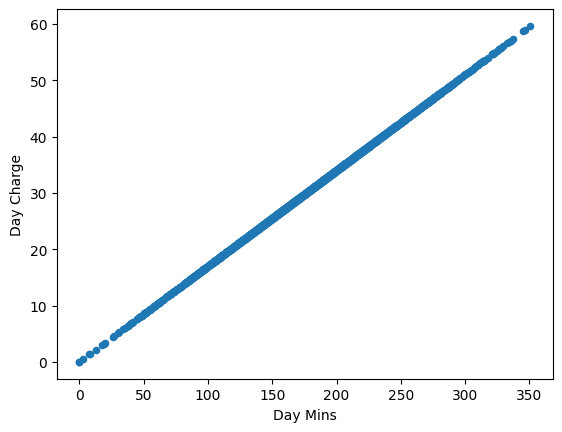

In [15]:
# scatter = dispersión
data1.plot(kind = "scatter", x = "Day Mins", y = "Day Charge")
# Notamos una correlación (lineal)

<Axes: xlabel='Night Mins', ylabel='Night Charge'>

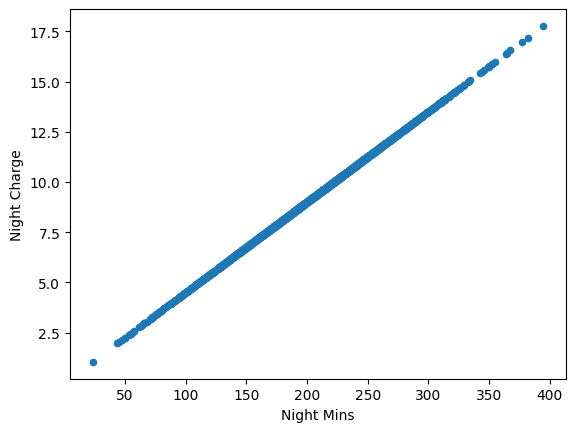

In [16]:
data1.plot(kind = "scatter", x = "Night Mins", y = "Night Charge")
# Notamos una correlación lineal

<Axes: xlabel='Day Calls', ylabel='Day Charge'>

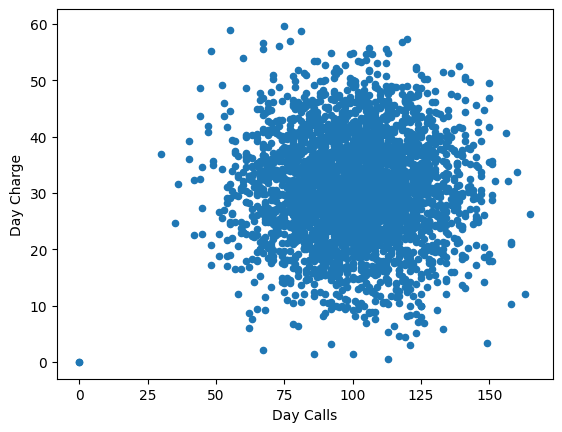

In [17]:
data1.plot(kind = "scatter", x = "Day Calls", y = "Day Charge")
# No hay ninguna relación aparente

<Axes: xlabel='Night Calls', ylabel='Night Charge'>

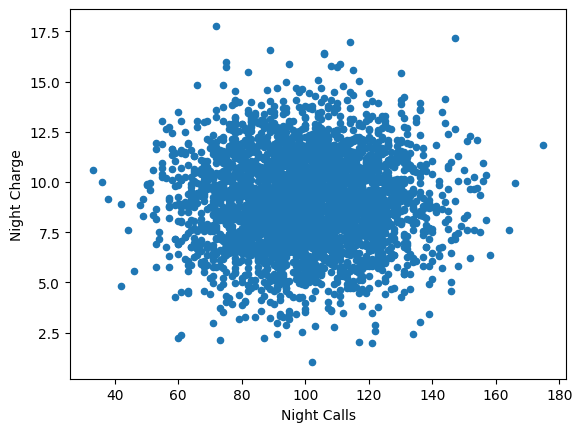

In [18]:
data1.plot(kind = "scatter", x = "Night Calls", y = "Night Charge")
# No hay ninguna relación aparente

##Podemos representar varios gráficos en una sola figura:

<Axes: xlabel='Night Calls', ylabel='Night Charge'>

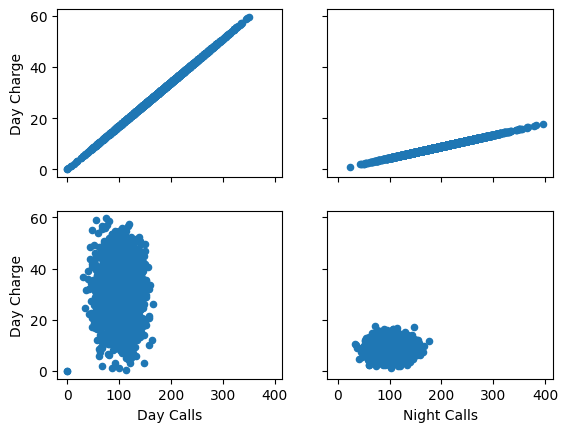

In [25]:
figure, axs = plt.subplots(2, 2, sharex = True, sharey = True)
data1.plot(kind = "scatter", x = "Day Mins", y = "Day Charge", ax = axs[0][0])
data1.plot(kind = "scatter", x = "Night Mins", y = "Night Charge", ax = axs[0][1])
data1.plot(kind = "scatter", x = "Day Calls", y = "Day Charge", ax = axs[1][0])
data1.plot(kind = "scatter", x = "Night Calls", y = "Night Charge", ax = axs[1][1])

#Histogramas de Frecuencias:

In [26]:
# Revisemos el número de objetos (observaciones) en data1 (número de filas)
data1.shape[0]

3333

In [27]:
print(np.ceil(1 + np.log2(3333)))
print(int(np.ceil(1 + np.log2(3333))))

13.0
13


Text(0.5, 1.0, 'Histograma del número de llamadas al día')

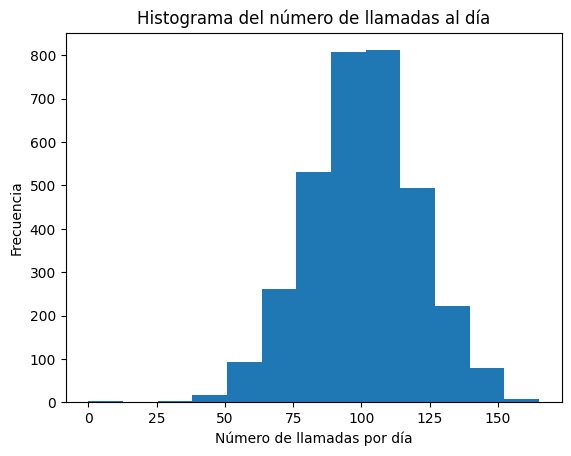

In [28]:
# Establecemos la constante k que se refiere a la fórmula de Sturges para visualizar histogramas
# El número de Sturges nos permite calcular el número óptimo para intervalos o marcas de clase
k = int(np.ceil(1 + np.log2(3333)))
plt.hist(data1["Day Calls"], bins = k)
plt.xlabel("Número de llamadas por día")
plt.ylabel("Frecuencia")
plt.title("Histograma del número de llamadas al día")

##Boxplots, diagrama de caja y bigotes

Text(0.5, 1.0, 'Boxplot de las llamadas diarias')

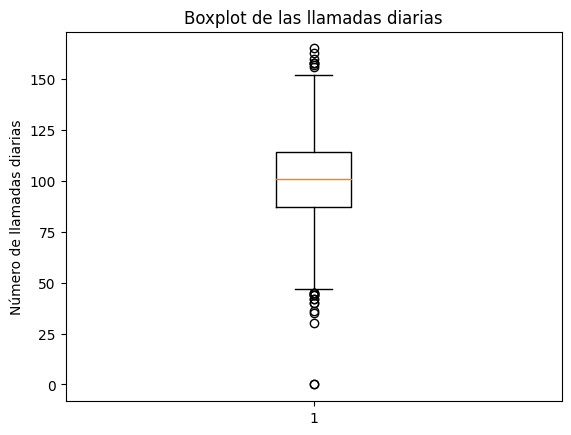

In [29]:
plt.boxplot(data1["Day Calls"])
plt.ylabel("Número de llamadas diarias")
plt.title("Boxplot de las llamadas diarias")

In [30]:
data1["Day Calls"].describe()

count    3333.000000
mean      100.435644
std        20.069084
min         0.000000
25%        87.000000
50%       101.000000
75%       114.000000
max       165.000000
Name: Day Calls, dtype: float64

In [31]:
# Para determinar el rango intercuartílico (usamos el método .quantile()):
# Por ejemplo, si deseamos conocer el cuartil 75, en el método escribimos .quantile(0.75)

IQR = data1["Day Calls"].quantile(0.75)-data1["Day Calls"].quantile(0.25)
IQR

27.0

In [ ]:
# Para determinar la altura de la raya que está por debajo del cuartil 25:

data1["Day Calls"].quantile(0.25) - 1.5*IQR

46.5

In [ ]:
# Para determinar la altura de la raya que está por encima del cuartil 75:

data1["Day Calls"].quantile(0.75) + 1.5*IQR

154.5